In [1]:
import numpy as np
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt

# The equation
$$
    \begin{cases}
    &Dy'' - vy' - ky = 0\\
    &Dy'(0) - vy(0) = j0\\
    &Dy'(L) - vy(L) = 0
    \end{cases}
$$

or with the solver

\begin{equation}
    \begin{cases}
        &y' = z \\
        &z' = ky + vz
    \end{cases}
\end{equation}

In [146]:
D = 0.9
v = 0.01
k = 1e-5
L = 500
j0= -0.1

# D = .1
# v = 0.0007
# k = 1e-5
# L = 500
# j0= -0.1

def f(t,y):
    return np.array([y[1], k/D*y[0] + v/D*y[1]])

def bc(y0, yL):
    return np.array([y0[1] - v/D*y0[0] - j0/D,
                     yL[1] - v/D*yL[0]])


# For the analytical steady state
sqrtD = np.sqrt(v**2 + 4 * D * k)

def ss(x):
    C = 2*j0/(1-np.exp(sqrtD/D*L)) * np.exp(v/2/D*x)

    right_1 = np.exp(sqrtD/2/D*x)/(sqrtD - v)
    right_2 = np.exp(-sqrtD/2/D*(x-2*L))/(sqrtD + v)

    return C * (right_1 + right_2)

x = np.linspace(0,L,1000)
yi = np.zeros((2,x.shape[0]))

yi[0,500] = 1

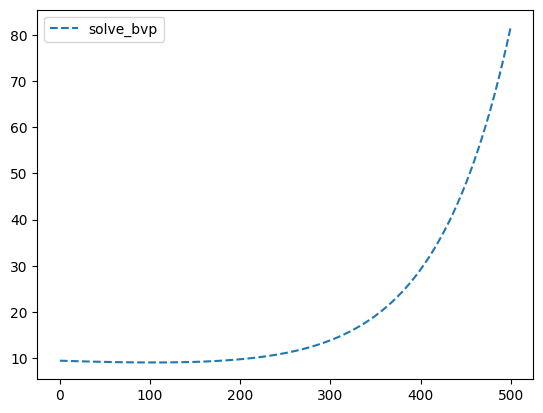

In [147]:
x_plot = np.linspace(0,L,1000)
y_plot = ss(x_plot)

y_prime = np.diff(y_plot)

fig, ax = plt.subplots(1,1)
ax.plot(x_plot, y_plot, linestyle='--', label='solve_bvp')
# ax.set_ylim(0, y_plot.max()*1.1);
# ax.plot(x_plot, ss(x_plot), label='analytical?')

# ax.set_ylim(0.1,0.3)
ax.legend()


[]

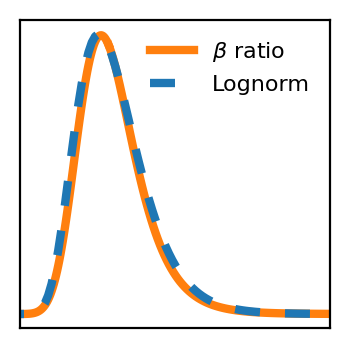

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import poch, factorial
from scipy.stats import lognorm

def g(x):
    res = 0
    for n in range(13):
        res += poch(26, n) * poch(-12, n) / poch(39, n) * x**n / factorial(n)

    return res*x**(12)*6e4

def h(x):
    res = 0
    for n in range(13):
        res += poch(26, n) * poch(-12, n) / poch(39, n) * x**(-n) / factorial(n)

    return res*x**(-14)*6e4

x_left = np.linspace(0,1,100)
x_right = np.linspace(1,3,100)
x_tot = np.linspace(0,3,100)

fig, axs = plt.subplots(1,1,figsize=(2,2), dpi=200)

ax = axs
c='tab:orange'
ax.plot(x_left, g(x_left), c=c, linewidth=3)
ax.plot(x_right, h(x_right), c=c, linewidth=3, label=r'$\beta$ ratio')

c = 'tab:blue'

ax.plot(x_tot, lognorm.pdf(x_tot, 0.30), linewidth=3, linestyle=(0,(3,3)), c=c,
        label='Lognorm')

ax.legend(frameon=False, fontsize=8)
# ax.set_xscale('log')
ax.set_xlim(0.2, 3)

ax.set_xticks([])
ax.set_yticks([])

# for k, v in ax.spines.items():
#     if k != 'bottom': v.set_visible(False)